In [1]:
import copy
import os

import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [3]:
def sample_circle(n, device=device):
    theta = 2 * np.pi * torch.rand(n, device=device)
    return torch.stack([torch.cos(theta), torch.sin(theta)], dim=-1)


def sample_xt(n, device=device):
    z = sample_circle(n, device)
    eps = torch.randn_like(z)
    t = torch.rand(n, 1, device=device)
    x = t * z + (1 - t) * eps
    return x, t, z - eps


class FMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 32), nn.SiLU(),
            nn.Linear(32, 32), nn.SiLU(),
            nn.Linear(32, 32), nn.SiLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=-1))


def train(net, total_steps=50000, batch_size=4096, lr=1e-4):
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_steps)
    for step in range(total_steps):
        x, t, v = sample_xt(batch_size, device=device)
        loss = (net(x, t) - v).pow(2).mean()
        opt.zero_grad(); loss.backward(); opt.step(); scheduler.step()
        if (step + 1) % 10000 == 0:
            print(f"step={step+1:6d}  loss={loss.item():.6f}")


net = FMNet().to(device)
train(net)

step= 10000  loss=0.964857


KeyboardInterrupt: 

In [4]:
from scipy.special import ive

def _true_velocity(pts_np, t_val):
    x1, x2 = pts_np[:, 0], pts_np[:, 1]
    r = np.sqrt(x1**2 + x2**2) + 1e-12
    s = max(1 - t_val, 1e-6)
    kappa = t_val * r / s**2
    A = ive(1, kappa) / (ive(0, kappa) + 1e-12)
    x_hat = pts_np / r[:, None]
    return ((A - r) / s)[:, None] * x_hat


def _sample_pt(t_val, n=5000):
    theta = 2 * np.pi * np.random.rand(n)
    z = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    eps = np.random.randn(n, 2)
    return t_val * z + (1 - t_val) * eps


def _hessian_eigenvalues(r_arr, t_val):
    """Eigenvalues of -∇² log p_t at radius r.

    λ_n (radial):    1/s² − t²/s⁴ · A'(κ)   where A'(κ) = 1 − A/κ − A²
    λ_t (tangential): (r − t·A) / (r·s²)
    """
    s = max(1 - t_val, 1e-6)
    kappa = t_val * r_arr / s**2
    A = ive(1, kappa) / (ive(0, kappa) + 1e-12)
    Aprime = 1.0 - A / (kappa + 1e-12) - A**2
    lambda_n = 1.0 / s**2 - (t_val**2 / s**4) * Aprime
    lambda_t = (r_arr - t_val * A) / (r_arr * s**2)
    return lambda_n, lambda_t


def _error_normal_tangent(samples, t_val):
    """Decompose (v_true - v_learned) into radial (normal) and tangential components."""
    pts = torch.tensor(samples, dtype=torch.float32, device=device)
    tt  = torch.full((pts.shape[0], 1), t_val, device=device, dtype=torch.float32)
    net.eval()
    with torch.no_grad():
        v_learned = net(pts, tt).cpu().numpy()

    error = _true_velocity(samples, t_val) - v_learned

    r = np.sqrt(samples[:, 0]**2 + samples[:, 1]**2) + 1e-12
    n_hat = samples / r[:, None]               # radial (normal to circle)
    t_hat = np.stack([-n_hat[:, 1], n_hat[:, 0]], axis=1)  # tangential

    e_n = np.sum(error * n_hat, axis=1)
    e_t = np.sum(error * t_hat, axis=1)
    return e_n, e_t, r

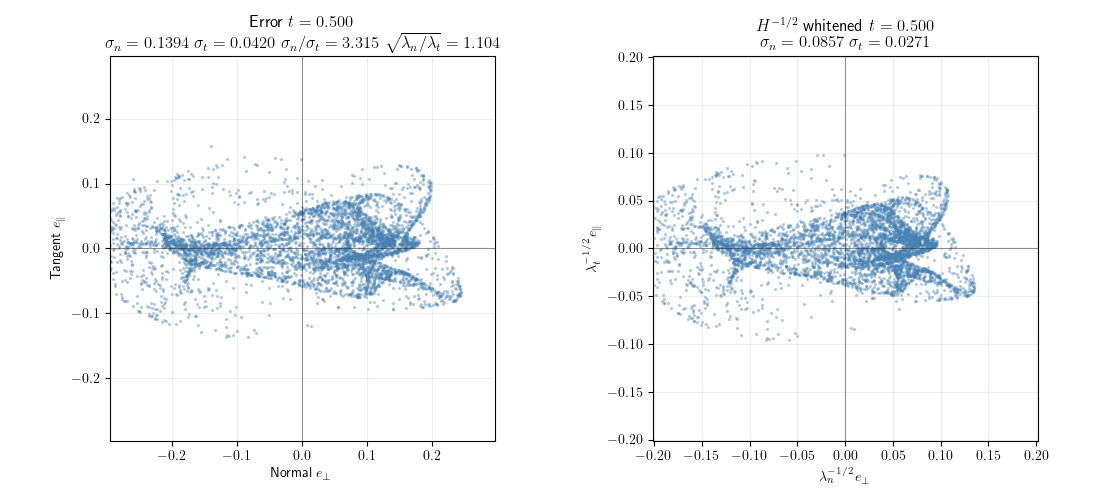

In [5]:
%matplotlib widget
import ipywidgets as widgets
from ipywidgets import VBox

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.canvas.toolbar_visible = False
fig.canvas.layout.width = '100%'


def _scatter_panel(ax, xdata, ydata, title, xlabel, ylabel):
    finite = np.isfinite(xdata) & np.isfinite(ydata)
    xdata, ydata = xdata[finite], ydata[finite]
    if len(xdata) == 0:
        ax.cla(); ax.set_title(title); return
    lim = max(np.percentile(np.abs(np.concatenate([xdata, ydata])), 99), 0.1)
    ax.cla()
    ax.scatter(xdata, ydata, s=2, alpha=0.3, color='steelblue', rasterized=True)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.4)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)


def redraw(t_val):
    samples = _sample_pt(t_val, n=5000)
    e_n, e_t, r = _error_normal_tangent(samples, t_val)
    lambda_n, lambda_t = _hessian_eigenvalues(r, t_val)

    # whiten: H^{-1/2} e — scale each component by 1/sqrt(eigenvalue)
    safe_n = np.sqrt(np.maximum(lambda_n, 1e-10))
    safe_t = np.sqrt(np.maximum(lambda_t, 1e-10))
    e_n_w = e_n / safe_n
    e_t_w = e_t / safe_t

    ratio_sigma = e_n.std() / (e_t.std() + 1e-12)
    ratio_eig   = np.sqrt(np.abs(np.mean(lambda_n) / (np.mean(lambda_t) + 1e-12)))

    _scatter_panel(
        axes[0], e_n, e_t,
        f'Error  $t={t_val:.3f}$\n'
        f'$\\sigma_n={e_n.std():.4f}$  $\\sigma_t={e_t.std():.4f}$  '
        f'$\\sigma_n/\\sigma_t={ratio_sigma:.3f}$  $\\sqrt{{\\lambda_n/\\lambda_t}}={ratio_eig:.3f}$',
        r'Normal $e_\perp$', r'Tangent $e_\parallel$',
    )
    _scatter_panel(
        axes[1], e_n_w, e_t_w,
        f'$H^{{-1/2}}$ whitened  $t={t_val:.3f}$\n$\\sigma_n={e_n_w.std():.4f}$  $\\sigma_t={e_t_w.std():.4f}$',
        r'$\lambda_n^{-1/2}\,e_\perp$', r'$\lambda_t^{-1/2}\,e_\parallel$',
    )

    fig.tight_layout()
    fig.canvas.draw_idle()


slider = widgets.FloatLogSlider(
    value=0.5, base=10, min=-2, max=0, step=0.05,
    description='1-t', continuous_update=False,
)
slider.observe(lambda change: redraw(1 - change['new']), names='value')

display(VBox([slider, fig.canvas]))
redraw(1 - slider.value)
